# 10 — Onset Evaluation

Drop-in addendum that retunes thresholds for **event-based onset CSI** and
recomputes onset-focused metrics (POD, FAR, CSI, HSS, lead time) for every
probability stream produced upstream. This notebook does **not** retrain
any model — it only consumes existing artifacts under
`output_refactored/intermediate/`.

Run after notebooks 03, 04, 04b, and 06 have completed.


In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shared_config import (
    INTERMEDIATE_DIR,
    OUTPUT_DIR,
    LSTM_TEST_PROBS_PATH,
    LSTM_ENKF_TEST_PROBS_PATH,
    ALT_MODEL_STREAMS_PATH,
    MC_PREDS_PATH,
    MC_DROPOUT_PREDS_PATH,
    RAW_TUNED_SEQUENCES_PATH,
)
from pipeline_utils import (
    load_sequence_artifact,
    best_f1_threshold,
    evaluate_probability_stream,
    write_json,
)
import onset_utils as ou

ONSET_BUFFER_WEEKS = 4   # weeks of bloom-free history that define an onset
EVENT_WINDOW = 2         # +/- tolerance for matching predicted to true events
LEAD_WINDOW = 6          # widen window for lead-time histograms

ONSET_OUTPUT_DIR = Path(OUTPUT_DIR) / "onset_evaluation"
ONSET_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Outputs will be written under: {ONSET_OUTPUT_DIR}")


Outputs will be written under: output_refactored\onset_evaluation


## 1. Load the test ground-truth and all probability streams

The standalone LSTM, EnKF-preprocessed LSTM, and alternative-model streams
are loaded from the artifact directory. Any stream that fails to load is
skipped with a printed warning so this notebook is robust to partial runs.


In [2]:
# Test ground truth from the raw tuned sequence artifact
seq = load_sequence_artifact(RAW_TUNED_SEQUENCES_PATH)
y_test = np.asarray(seq["y_test"]).astype(int).flatten()
print(f"y_test length: {len(y_test)} | positives: {int(y_test.sum())} "
      f"({100 * y_test.mean():.1f}%)")

# Onset target (the new quantity of interest)
y_onset = ou.make_onset_target(y_test, buffer_weeks=ONSET_BUFFER_WEEKS)
n_events = int(y_onset.sum())
print(f"Onset events in test set (buffer={ONSET_BUFFER_WEEKS}w): {n_events}")
if n_events == 0:
    raise RuntimeError(
        "No onset events found in y_test under the chosen buffer. "
        "Lower ONSET_BUFFER_WEEKS or check the test split."
    )


y_test length: 216 | positives: 70 (32.4%)
Onset events in test set (buffer=4w): 3


In [3]:
streams = {}

def _aligned_stream_inputs(probs):
    probs = np.asarray(probs, dtype=float).flatten()
    n = min(len(probs), len(y_test))
    y_binary = y_test[-n:]
    probs = probs[-n:]
    y_onset_i = ou.make_onset_target(y_binary, buffer_weeks=ONSET_BUFFER_WEEKS)
    return y_binary, y_onset_i, probs


def _maybe_load_npy(name, path):
    if not os.path.exists(path):
        print(f"  [skip] {name}: {path} not found")
        return
    arr = np.load(path)
    arr = np.asarray(arr).flatten()
    if len(arr) != len(y_test):
        print(f"  [align] {name}: stream length {len(arr)} vs raw y_test {len(y_test)}; metrics use trailing overlap")
    streams[name] = arr
    print(f"  [ok]   {name}: shape={arr.shape}, "
          f"mean={arr.mean():.3f}, max={arr.max():.3f}")

print("Loading single-point probability streams:")
_maybe_load_npy("LSTM", LSTM_TEST_PROBS_PATH)
_maybe_load_npy("LSTM_EnKF", LSTM_ENKF_TEST_PROBS_PATH)

# Alternative model streams (npz with one key per model)
if os.path.exists(ALT_MODEL_STREAMS_PATH):
    with np.load(ALT_MODEL_STREAMS_PATH, allow_pickle=True) as alt:
        for key in alt.files:
            if key == "y_test":
                continue
            arr = np.asarray(alt[key]).flatten()
            if len(arr) != len(y_test):
                print(f"  [align] alt_{key}: stream length {len(arr)} vs raw y_test {len(y_test)}; metrics use trailing overlap")
            streams[f"alt_{key}"] = arr
    print(f"  [ok]   alternative streams: {[k for k in alt.files if k != 'y_test']}")
else:
    print(f"  [skip] alt_model_streams: {ALT_MODEL_STREAMS_PATH} not found")

# 3-D MC tensor for probabilistic alerts (notebook 04b output)
mc_tensor = None
if os.path.exists(MC_PREDS_PATH):
    mc_tensor = np.load(MC_PREDS_PATH)
    print(f"  [ok]   MC tensor: shape={mc_tensor.shape}")
elif os.path.exists(MC_DROPOUT_PREDS_PATH):
    mc_tensor = np.load(MC_DROPOUT_PREDS_PATH)
    print(f"  [ok]   MC-dropout matrix: shape={mc_tensor.shape}")
else:
    print(f"  [skip] MC tensor: {MC_PREDS_PATH} not found")

print(f"\nLoaded {len(streams)} probability streams.")


Loading single-point probability streams:
  [ok]   LSTM: shape=(216,), mean=0.553, max=0.993
  [ok]   LSTM_EnKF: shape=(216,), mean=0.547, max=0.971
  [ok]   alternative streams: ['lstm', 'lstm_enkf_preprocessor', 'var', 'regime_switching', 'pinn', 'lstm_gp', 'hybrid_ensemble']
  [ok]   MC tensor: shape=(216, 50, 50)

Loaded 9 probability streams.


## 2. Baseline: evaluate at the current global-F1 threshold

This is what the existing pipeline reports. We compute it here so the
onset-aware results can be compared on the same plot.


In [4]:
rows_global = []
for name, probs in streams.items():
    y_binary_i, y_onset_i, probs_i = _aligned_stream_inputs(probs)
    thr_f1 = best_f1_threshold(y_binary_i, probs_i, fallback=0.5)
    y_pred = (probs_i >= thr_f1).astype(int)
    ev = ou.event_based_metrics(y_onset_i, y_pred, window=EVENT_WINDOW)
    rows_global.append({
        "model": name,
        "threshold_rule": "global_F1",
        "threshold": round(thr_f1, 4),
        "POD": round(ev["POD"], 3),
        "FAR": round(ev["FAR"], 3),
        "CSI": round(ev["CSI"], 3),
        "HSS": round(ev["HSS"], 3),
        "event_F1": round(ev["event_F1"], 3),
        "hits": ev["hits"],
        "misses": ev["misses"],
        "false_alarms": ev["false_alarms"],
        "n_true_events": ev["n_true_events"],
    })

df_global = pd.DataFrame(rows_global).sort_values("CSI", ascending=False)
df_global


,model,threshold_rule,threshold,POD,FAR,CSI,HSS,event_F1,hits,misses,false_alarms,n_true_events
0,LSTM,global_F1,0.8116,1.000,0.955,0.045,0.061,0.086,3,0,64,3
2,alt_lstm,global_F1,0.8116,1.000,0.955,0.045,0.061,0.086,3,0,64,3
4,alt_var,global_F1,0.3206,1.000,0.957,0.043,0.057,0.082,3,0,67,3
7,alt_lstm_gp,global_F1,0.6566,1.000,0.957,0.043,0.058,0.083,3,0,66,3
6,alt_pinn,global_F1,0.7112,1.000,0.957,0.043,0.057,0.082,3,0,67,3
8,alt_hybrid_ensemble,global_F1,0.6455,1.000,0.957,0.043,0.057,0.082,3,0,67,3
5,alt_regime_switching,global_F1,0.7000,1.000,0.959,0.041,0.054,0.079,3,0,70,3
3,alt_lstm_enkf_preprocessor,global_F1,0.7211,0.667,0.972,0.027,0.027,0.053,2,1,70,3
1,LSTM_EnKF,global_F1,0.7211,0.667,0.972,0.027,0.027,0.053,2,1,70,3


## 3. Retune each threshold for onset CSI

For each stream, sweep thresholds and pick the one that maximizes
event-based CSI (positive predictions matched to true onsets within
+/- EVENT_WINDOW weeks). This is the cheap, no-retraining gain.


In [5]:
rows_onset = []
onset_thresholds = {}
for name, probs in streams.items():
    y_binary_i, y_onset_i, probs_i = _aligned_stream_inputs(probs)
    thr_onset, ev = ou.best_onset_csi_threshold(
        probs_i,
        y_binary_i,
        buffer_weeks=ONSET_BUFFER_WEEKS,
        window=EVENT_WINDOW,
    )
    onset_thresholds[name] = thr_onset
    rows_onset.append({
        "model": name,
        "threshold_rule": "onset_CSI",
        "threshold": round(thr_onset, 4),
        "POD": round(ev["POD"], 3),
        "FAR": round(ev["FAR"], 3),
        "CSI": round(ev["CSI"], 3),
        "HSS": round(ev["HSS"], 3),
        "event_F1": round(ev["event_F1"], 3),
        "hits": ev["hits"],
        "misses": ev["misses"],
        "false_alarms": ev["false_alarms"],
        "n_true_events": ev["n_true_events"],
    })

df_onset = pd.DataFrame(rows_onset).sort_values("CSI", ascending=False)
df_onset


,model,threshold_rule,threshold,POD,FAR,CSI,HSS,event_F1,hits,misses,false_alarms,n_true_events
1,LSTM_EnKF,onset_CSI,0.9351,0.667,0.778,0.200,0.319,0.333,2,1,7,3
3,alt_lstm_enkf_preprocessor,onset_CSI,0.9351,0.667,0.778,0.200,0.319,0.333,2,1,7,3
0,LSTM,onset_CSI,0.9687,1.000,0.833,0.167,0.268,0.286,3,0,15,3
2,alt_lstm,onset_CSI,0.9687,1.000,0.833,0.167,0.268,0.286,3,0,15,3
4,alt_var,onset_CSI,0.6259,0.667,0.833,0.154,0.250,0.267,2,1,10,3
6,alt_pinn,onset_CSI,0.8230,0.333,0.800,0.143,0.237,0.250,1,2,4,3
7,alt_lstm_gp,onset_CSI,0.7889,1.000,0.857,0.143,0.231,0.250,3,0,18,3
8,alt_hybrid_ensemble,onset_CSI,0.9113,0.667,0.905,0.091,0.146,0.167,2,1,19,3
5,alt_regime_switching,onset_CSI,0.9446,0.667,0.909,0.087,0.139,0.160,2,1,20,3


## 4. Side-by-side comparison

The same models, evaluated under both threshold rules, sorted by onset CSI.
The headline number to put in the manuscript is the **CSI delta** between
the two rules: how much onset skill the global-F1 threshold is leaving on
the table.


In [6]:
df_compare = (
    pd.concat([df_global, df_onset], ignore_index=True)
    .pivot(index="model", columns="threshold_rule",
           values=["threshold", "POD", "FAR", "CSI", "HSS", "event_F1"])
)
df_compare["CSI_gain"] = (
    df_compare[("CSI", "onset_CSI")] - df_compare[("CSI", "global_F1")]
)
df_compare = df_compare.sort_values("CSI_gain", ascending=False)
df_compare


threshold                 POD                 FAR  \
threshold_rule             global_F1 onset_CSI global_F1 onset_CSI global_F1   
model                                                                          
LSTM_EnKF                     0.7211    0.9351     0.667     0.667     0.972   
alt_lstm_enkf_preprocessor    0.7211    0.9351     0.667     0.667     0.972   
LSTM                          0.8116    0.9687     1.000     1.000     0.955   
alt_lstm                      0.8116    0.9687     1.000     1.000     0.955   
alt_var                       0.3206    0.6259     1.000     0.667     0.957   
alt_pinn                      0.7112    0.8230     1.000     0.333     0.957   
alt_lstm_gp                   0.6566    0.7889     1.000     1.000     0.957   
alt_hybrid_ensemble           0.6455    0.9113     1.000     0.667     0.957   
alt_regime_switching          0.7000    0.9446     1.000     0.667     0.959   

                                           CSI                 HSS            \
threshold_rule             onset_CSI global_F1 onset_CSI global_F1 onset_CSI   
model                                                                          
LSTM_EnKF                      0.778     0.027     0.200     0.027     0.319   
alt_lstm_enkf_preprocessor     0.778     0.027     0.200     0.027     0.319   
LSTM                           0.833     0.045     0.167     0.061     0.268   
alt_lstm                       0.833     0.045     0.167     0.061     0.268   
alt_var                        0.833     0.043     0.154     0.057     0.250   
alt_pinn                       0.800     0.043     0.143     0.057     0.237   
alt_lstm_gp                    0.857     0.043     0.143     0.058     0.231   
alt_hybrid_ensemble            0.905     0.043     0.091     0.057     0.146   
alt_regime_switching           0.909     0.041     0.087     0.054     0.139   

                            event_F1           CSI_gain  
threshold_rule             global_F1 onset_CSI           
model                                                    
LSTM_EnKF                      0.053     0.333    0.173  
alt_lstm_enkf_preprocessor     0.053     0.333    0.173  
LSTM                           0.086     0.286    0.122  
alt_lstm                       0.086     0.286    0.122  
alt_var                        0.082     0.267    0.111  
alt_pinn                       0.082     0.250    0.100  
alt_lstm_gp                    0.083     0.250    0.100  
alt_hybrid_ensemble            0.082     0.167    0.048  
alt_regime_switching           0.079     0.160    0.046

## 5. Lead-time distribution at the onset-CSI threshold

Positive lead time = model alerted before the true onset week. NaN entries
in the distribution correspond to onsets the model failed to catch within
LEAD_WINDOW. The median and IQR are the operationally meaningful summaries.


In [7]:
lead_rows = []
lead_arrays = {}
for name, probs in streams.items():
    y_binary_i, y_onset_i, probs_i = _aligned_stream_inputs(probs)
    thr = onset_thresholds[name]
    y_pred = (probs_i >= thr).astype(int)
    leads = ou.onset_lead_times(y_onset_i, y_pred, window=LEAD_WINDOW)
    lead_arrays[name] = leads
    finite = leads[np.isfinite(leads)]
    lead_rows.append({
        "model": name,
        "n_onsets": int(np.isfinite(leads).size),
        "n_detected": int(np.isfinite(leads).sum()),
        "lead_median_w": float(np.nanmedian(leads)) if finite.size else np.nan,
        "lead_p25_w": float(np.nanpercentile(leads, 25)) if finite.size else np.nan,
        "lead_p75_w": float(np.nanpercentile(leads, 75)) if finite.size else np.nan,
        "lead_min_w": float(np.nanmin(leads)) if finite.size else np.nan,
        "lead_max_w": float(np.nanmax(leads)) if finite.size else np.nan,
    })

df_leads = pd.DataFrame(lead_rows).sort_values("lead_median_w", ascending=False)
df_leads


,model,n_onsets,n_detected,lead_median_w,lead_p25_w,lead_p75_w,lead_min_w,lead_max_w
0,LSTM,3,3,-1.0,-1.5,-1.0,-2.0,-1.0
2,alt_lstm,3,3,-1.0,-1.5,-1.0,-2.0,-1.0
6,alt_pinn,3,1,-1.0,-1.0,-1.0,-1.0,-1.0
7,alt_lstm_gp,3,3,-1.0,-1.5,2.5,-2.0,6.0
1,LSTM_EnKF,3,3,-2.0,-3.5,-2.0,-5.0,-2.0
4,alt_var,3,3,-2.0,-3.5,-2.0,-5.0,-2.0
3,alt_lstm_enkf_preprocessor,3,3,-2.0,-3.5,-2.0,-5.0,-2.0
5,alt_regime_switching,3,3,-2.0,-3.5,-2.0,-5.0,-2.0
8,alt_hybrid_ensemble,3,3,-2.0,-3.5,-2.0,-5.0,-2.0


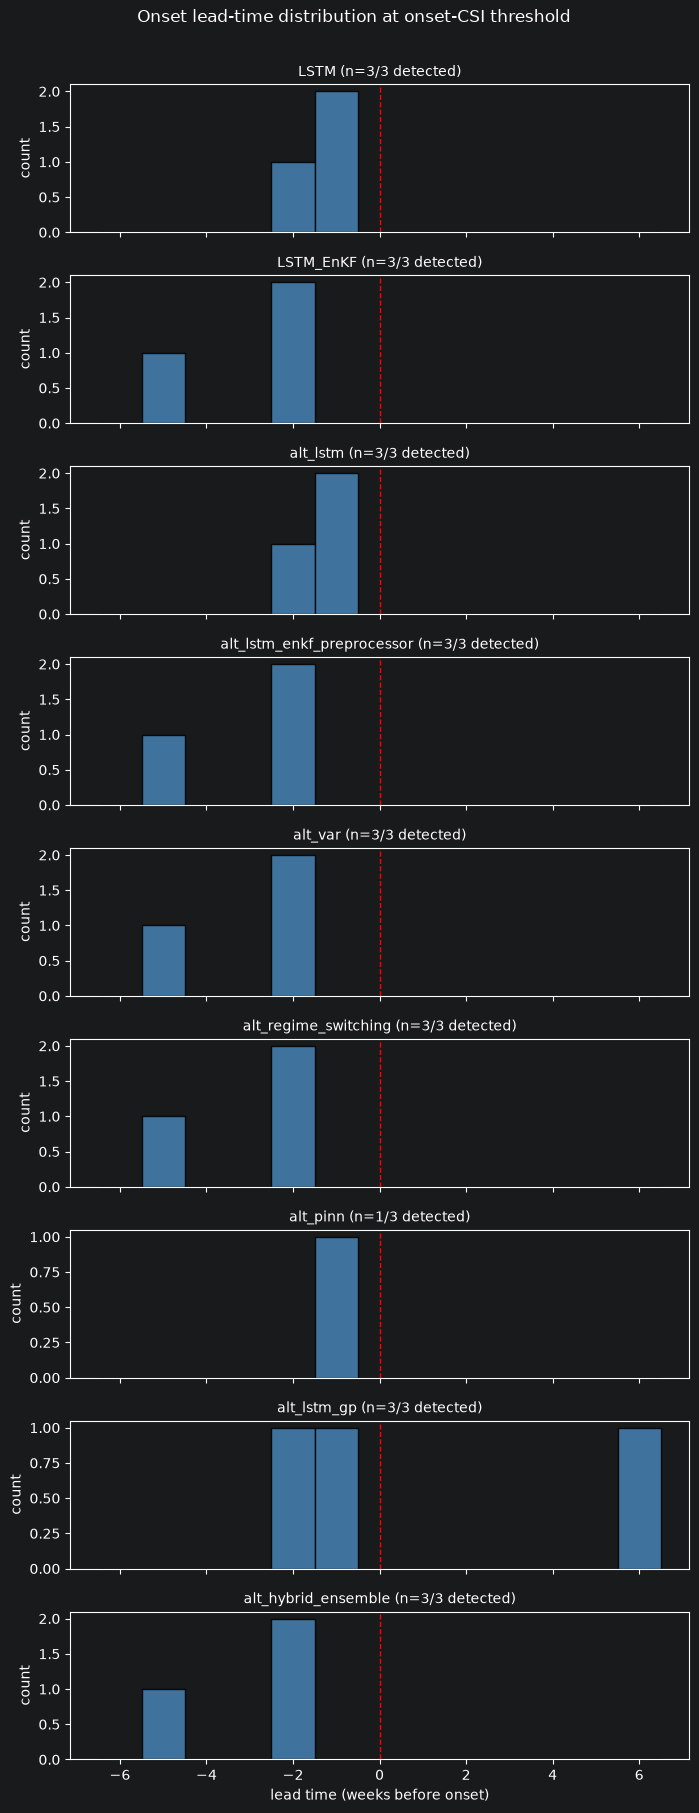

In [8]:
# Lead-time histogram per model
n_models = len(lead_arrays)
fig, axes = plt.subplots(
    nrows=n_models, ncols=1,
    figsize=(7, 2.0 * max(n_models, 1)),
    sharex=True,
)
if n_models == 1:
    axes = [axes]
bins = np.arange(-LEAD_WINDOW - 0.5, LEAD_WINDOW + 1.5, 1)
for ax, (name, leads) in zip(axes, lead_arrays.items()):
    finite = leads[np.isfinite(leads)]
    ax.hist(finite, bins=bins, color="steelblue", edgecolor="black", alpha=0.85)
    ax.axvline(0, color="red", linestyle="--", linewidth=1, label="onset week")
    ax.set_title(f"{name} (n={len(finite)}/{len(leads)} detected)", fontsize=10)
    ax.set_ylabel("count")
axes[-1].set_xlabel("lead time (weeks before onset)")
fig.suptitle("Onset lead-time distribution at onset-CSI threshold", y=1.005)
fig.tight_layout()
fig.savefig(ONSET_OUTPUT_DIR / "lead_time_histograms.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Probabilistic ensemble onset alert (optional)

If notebook 04b has produced the 3-D MC tensor, we can build a
probabilistic onset alert from it: declare an alert when at least
``alert_fraction`` of ensemble members predict a bloom within the next
``horizon`` weeks. This combines uncertainty and lead time into a single
operational rule.


In [9]:
if mc_tensor is None:
    print("MC tensor not available; skipping ensemble-alert section.")
else:
    grid = []
    for af in [0.2, 0.3, 0.4, 0.5]:
        for h in [0, 2, 4]:
            alert = ou.ensemble_onset_alert(
                mc_tensor, threshold=0.5,
                alert_fraction=af, horizon=h,
            )
            if len(alert) != len(y_onset):
                a = alert[-min(len(alert), len(y_onset)):]
                yo = y_onset[-len(a):]
            else:
                a, yo = alert, y_onset
            ev = ou.event_based_metrics(yo, a, window=EVENT_WINDOW)
            grid.append({
                "alert_fraction": af,
                "horizon_w": h,
                "POD": round(ev["POD"], 3),
                "FAR": round(ev["FAR"], 3),
                "CSI": round(ev["CSI"], 3),
                "HSS": round(ev["HSS"], 3),
            })
    df_alert = pd.DataFrame(grid)
    print(df_alert)


    alert_fraction  horizon_w  POD    FAR    CSI    HSS
0              0.2          0  1.0  0.979  0.021  0.013
1              0.2          2  1.0  0.981  0.019  0.011
2              0.2          4  1.0  0.981  0.019  0.009
3              0.3          0  1.0  0.979  0.021  0.015
4              0.3          2  1.0  0.980  0.020  0.013
5              0.3          4  1.0  0.981  0.019  0.011
6              0.4          0  1.0  0.978  0.022  0.017
7              0.4          2  1.0  0.979  0.021  0.014
8              0.4          4  1.0  0.980  0.020  0.012
9              0.5          0  1.0  0.976  0.024  0.020
10             0.5          2  1.0  0.978  0.022  0.016
11             0.5          4  1.0  0.979  0.021  0.013


## 7. Persist results for the manuscript

Tables saved as CSV, summary saved as JSON, and the lead-time figure
already saved above. Drop these into notebook 07 / 08 outputs for the
final comparison.


In [10]:
df_global.to_csv(ONSET_OUTPUT_DIR / "metrics_global_f1.csv", index=False)
df_onset.to_csv(ONSET_OUTPUT_DIR / "metrics_onset_csi.csv", index=False)
df_compare.to_csv(ONSET_OUTPUT_DIR / "metrics_side_by_side.csv")
df_leads.to_csv(ONSET_OUTPUT_DIR / "lead_times.csv", index=False)

summary = {
    "onset_buffer_weeks": ONSET_BUFFER_WEEKS,
    "event_window_weeks": EVENT_WINDOW,
    "lead_window_weeks": LEAD_WINDOW,
    "n_test_timesteps": int(len(y_test)),
    "n_test_positives": int(y_test.sum()),
    "n_onset_events": int(y_onset.sum()),
    "thresholds_onset_csi": {k: float(v) for k, v in onset_thresholds.items()},
    "streams_evaluated": list(streams.keys()),
}
write_json(ONSET_OUTPUT_DIR / "onset_evaluation_summary.json", summary)
print(f"Wrote summary and tables to {ONSET_OUTPUT_DIR}")


Wrote summary and tables to output_refactored\onset_evaluation
